In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
batch_size = 64
image_size = 28
noise_size = 100
epochs = 20
learning_rate = 0.01

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.08MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.9MB/s]


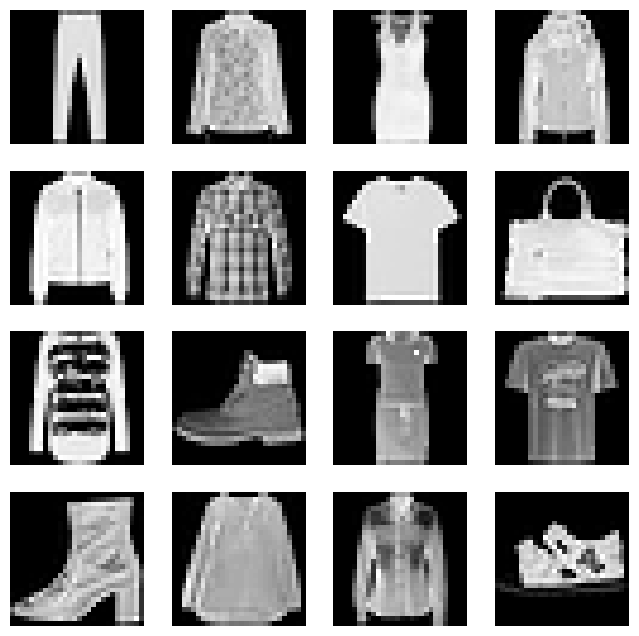

In [4]:
images, labels = next(iter(dataloader))

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.show()

In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.ConvTranspose2d(100, 128, 7, 1, 0),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

generator = Generator()

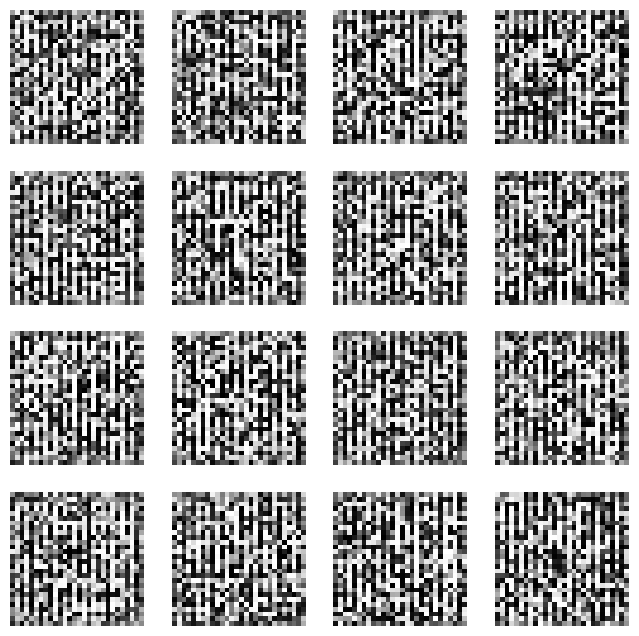

In [6]:
noise = torch.randn(16, 100, 1, 1)

fake_images = generator(noise)

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake_images[i].detach().squeeze(), cmap="gray")
    plt.axis("off")

plt.show()

In [7]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

discriminator = Discriminator()


In [8]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

In [9]:
G_losses = []
D_losses = []

In [10]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

GPU available: True
GPU: Tesla T4


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = generator.to(device)
discriminator = discriminator.to(device)

In [12]:
G_losses = []
D_losses = []

for epoch in range(20):

    for real_images, _ in dataloader:

        real_images = real_images.to(device)

        batch_size_now = real_images.size(0)

        real_labels = torch.ones(batch_size_now, 1).to(device)
        fake_labels = torch.zeros(batch_size_now, 1).to(device)

        # -----------------
        # Train Discriminator
        # -----------------

        output_real = discriminator(real_images)
        loss_real = criterion(output_real, real_labels)

        noise = torch.randn(batch_size_now, 100, 1, 1).to(device)
        fake_images = generator(noise)

        output_fake = discriminator(fake_images.detach())
        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # -----------------
        # Train Generator
        # -----------------

        noise = torch.randn(batch_size_now, 100, 1, 1).to(device)
        fake_images = generator(noise)

        output = discriminator(fake_images)

        loss_G = criterion(output, real_labels)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

    print(
        f"Epoch [{epoch+1}/20] "
        f"Generator Loss: {loss_G.item():.4f} "
        f"Discriminator Loss: {loss_D.item():.4f}"
    )

Epoch [1/20] Generator Loss: 100.0000 Discriminator Loss: 0.0000
Epoch [2/20] Generator Loss: 98.3837 Discriminator Loss: 0.0000
Epoch [3/20] Generator Loss: 99.2494 Discriminator Loss: 0.0000
Epoch [4/20] Generator Loss: 98.1272 Discriminator Loss: 0.0000
Epoch [5/20] Generator Loss: 98.8351 Discriminator Loss: 0.0000
Epoch [6/20] Generator Loss: 99.2190 Discriminator Loss: 0.0000
Epoch [7/20] Generator Loss: 97.5179 Discriminator Loss: 0.0000
Epoch [8/20] Generator Loss: 99.6148 Discriminator Loss: 0.0000
Epoch [9/20] Generator Loss: 98.4773 Discriminator Loss: 0.0000
Epoch [10/20] Generator Loss: 97.6986 Discriminator Loss: 0.0000
Epoch [11/20] Generator Loss: 97.6948 Discriminator Loss: 0.0000
Epoch [12/20] Generator Loss: 97.3705 Discriminator Loss: 0.0000
Epoch [13/20] Generator Loss: 97.2983 Discriminator Loss: 0.0000
Epoch [14/20] Generator Loss: 97.6714 Discriminator Loss: 0.0000
Epoch [15/20] Generator Loss: 97.5331 Discriminator Loss: 0.0000
Epoch [16/20] Generator Loss: 96.

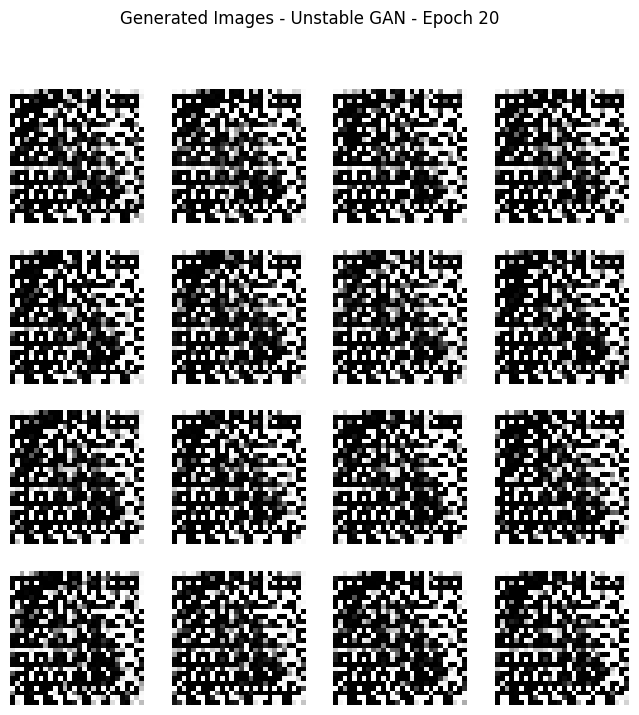

In [13]:
fixed_noise = torch.randn(16, 100, 1, 1).to(device)

with torch.no_grad():
    fake_images = generator(fixed_noise)

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake_images[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Generated Images - Unstable GAN - Epoch 20")
plt.show()

Part B


In [14]:
batch_size = 64
image_size = 28
noise_size = 100
epochs = 20
learning_rate = 0.0002

In [15]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [16]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

In [18]:
G_losses = []
D_losses = []

for epoch in range(20):

    for real_images, _ in dataloader:

        real_images = real_images.to(device)

        batch_size_now = real_images.size(0)

        # Label smoothing
        real_labels = torch.full(
            (batch_size_now, 1),
            0.9,
            device=device
        )

        fake_labels = torch.zeros(
            batch_size_now, 1,
            device=device
        )

        # -----------------
        # Train Discriminator
        # -----------------

        output_real = discriminator(real_images)
        loss_real = criterion(output_real, real_labels)

        noise = torch.randn(
            batch_size_now, 100, 1, 1,
            device=device
        )

        fake_images = generator(noise)

        output_fake = discriminator(fake_images.detach())
        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # -----------------
        # Train Generator
        # -----------------

        noise = torch.randn(
            batch_size_now, 100, 1, 1,
            device=device
        )

        fake_images = generator(noise)

        output = discriminator(fake_images)

        loss_G = criterion(output, real_labels)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

    print(
        f"Epoch [{epoch+1}/20] "
        f"Generator Loss: {loss_G.item():.4f} "
        f"Discriminator Loss: {loss_D.item():.4f}"
    )

Epoch [1/20] Generator Loss: 1.5576 Discriminator Loss: 0.8318
Epoch [2/20] Generator Loss: 1.1368 Discriminator Loss: 0.6479
Epoch [3/20] Generator Loss: 1.7240 Discriminator Loss: 0.9913
Epoch [4/20] Generator Loss: 1.4778 Discriminator Loss: 0.7641
Epoch [5/20] Generator Loss: 2.2968 Discriminator Loss: 0.7422
Epoch [6/20] Generator Loss: 1.0464 Discriminator Loss: 0.8260
Epoch [7/20] Generator Loss: 2.2412 Discriminator Loss: 0.9100
Epoch [8/20] Generator Loss: 1.7251 Discriminator Loss: 0.7608
Epoch [9/20] Generator Loss: 1.6356 Discriminator Loss: 0.9725
Epoch [10/20] Generator Loss: 1.7756 Discriminator Loss: 0.8332
Epoch [11/20] Generator Loss: 1.6898 Discriminator Loss: 0.9051
Epoch [12/20] Generator Loss: 2.1800 Discriminator Loss: 0.8550
Epoch [13/20] Generator Loss: 2.1534 Discriminator Loss: 0.7187
Epoch [14/20] Generator Loss: 2.3108 Discriminator Loss: 0.7887
Epoch [15/20] Generator Loss: 1.6414 Discriminator Loss: 0.6721
Epoch [16/20] Generator Loss: 1.6454 Discriminato

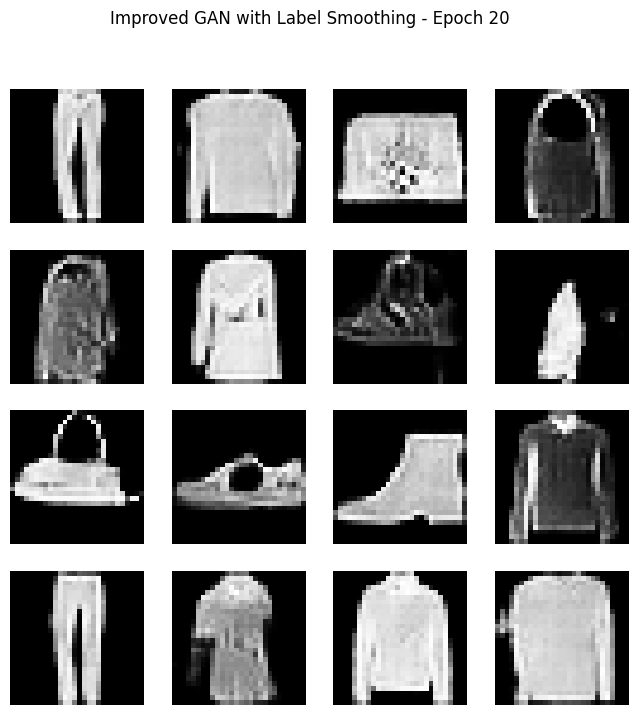

In [19]:
fixed_noise = torch.randn(16, 100, 1, 1).to(device)

with torch.no_grad():
    fake_images = generator(fixed_noise)

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake_images[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Improved GAN with Label Smoothing - Epoch 20")
plt.show()

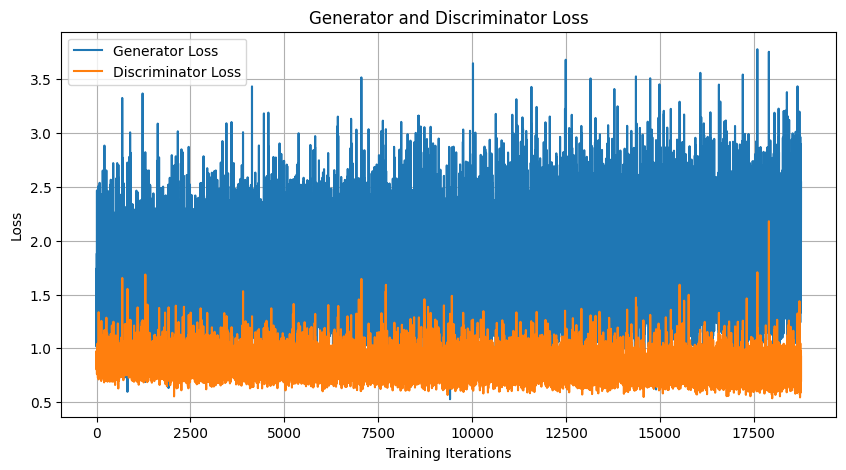

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.xlabel("Training Iterations")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Loss")
plt.legend()
plt.grid()

plt.show()

1. What modification caused the model to perform poorly?

I increased the learning rate from 0.0002 to 0.01. This made the GAN training unstable and caused the generator to produce poor-quality images.

2. What did the generated images look like?

The generated images were mostly random black-and-white noisy patterns and were not recognizable as Fashion-MNIST clothing images.

3. Which technique did you use to improve the problem?

I used label smoothing. The real labels were changed from 1.0 to 0.9, while the fake labels remained 0.0. I also changed the learning rate back to 0.0002.

4. Did the solution improve the output? Why?

Yes. The output improved significantly. After applying label smoothing, the generator produced more recognizable and varied clothing-like images. Label smoothing helped make the discriminator less overconfident and made the GAN training more stable.